In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

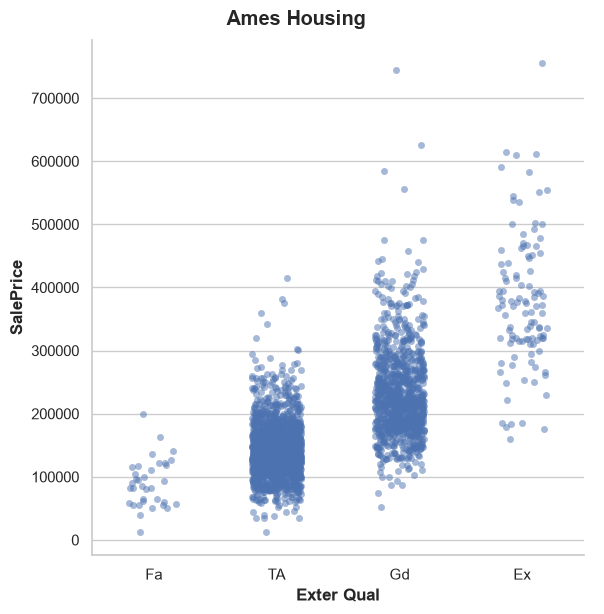

In [12]:
sns.set_theme(style="whitegrid")

df = pd.read_csv("../datasets/ames-housing-dataset/AmesHousing.csv")

g = sns.catplot(
    data=df,
    x="Exter Qual",
    y="SalePrice",
    kind="strip",
    order=["Fa", "TA", "Gd", "Ex"],
    jitter=0.2,
    alpha=0.5,
    height=6,
    aspect=1
)

sns.despine()

g.set_axis_labels("Exter Qual", "SalePrice", fontweight="bold")
g.fig.suptitle("Ames Housing", fontweight="bold", y=1.02)

plt.show()

In [13]:
df = pd.read_csv("../datasets/automobile-dataset/autos.csv")
#
# nums = {"zero": "0", "one": "1", "two": "2", "three": "3", "four": "4", "five": "5", "six": "6", "seven": "7", "eight": "8", "nine": "9", "ten": "10", "eleven": "11", "twelve": "12"}

# df["num-of-doors"] = df["num-of-doors"].map(lambda x: nums.get(x.lower().strip(), np.nan))
# df["num-of-cylinders"] = df["num-of-cylinders"].map(lambda x: nums.get(x.lower().strip(), np.nan))
# df.loc[27, "num-of-doors"] = "4"
# df.loc[63, "num-of-doors"] = "4"

# numeric_cols = [
#     "symboling",
#     "normalized-losses",
#     "num-of-doors",
#     "wheel-base",
#     "length",
#     "width",
#     "height",
#     "curb-weight",
#     "num-of-cylinders",
#     "bore",
#     "stroke",
#     "compression-ratio",
#     "horsepower",
#     "peak-rpm",
#     "city-mpg",
#     "highway-mpg",
#     "price"
# ]
#
# df[numeric_cols] = df[numeric_cols].apply(
#     pd.to_numeric, errors="coerce"
# )

df = df.replace("?", np.nan).dropna()

In [14]:
X = df.copy()
y = X.pop("price")

# Label encoding for categoricals
for colname in X.select_dtypes(include=["object", "str"]):
    X[colname], _ = X[colname].factorize()


# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int
discrete_features

symboling             True
make                  True
fuel_type             True
aspiration            True
num_of_doors          True
body_style            True
drive_wheels          True
engine_location       True
wheel_base           False
length               False
width                False
height               False
curb_weight           True
engine_type           True
num_of_cylinders      True
engine_size           True
fuel_system           True
bore                 False
stroke               False
compression_ratio     True
horsepower            True
peak_rpm              True
city_mpg              True
highway_mpg           True
dtype: bool

In [15]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]  # show a few features with their MI scores

curb_weight          1.516989
highway_mpg          0.953066
length               0.610039
fuel_system          0.483034
stroke               0.379725
drive_wheels         0.332448
compression_ratio    0.132211
fuel_type            0.047279
Name: MI Scores, dtype: float64

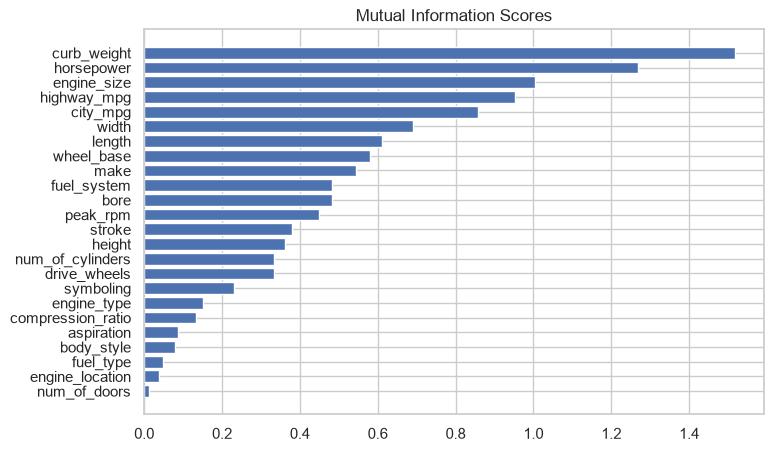

In [16]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

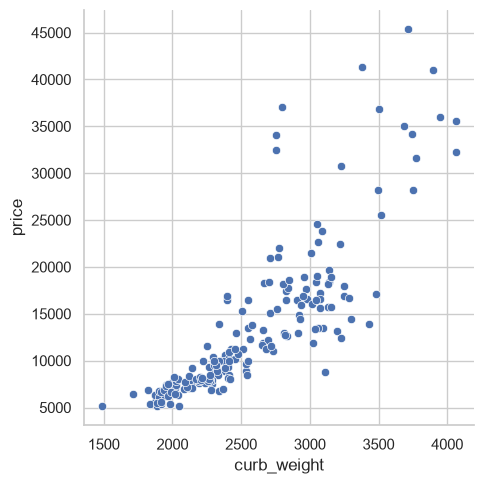

In [19]:
sns.relplot(x="curb_weight", y="price", data=df);

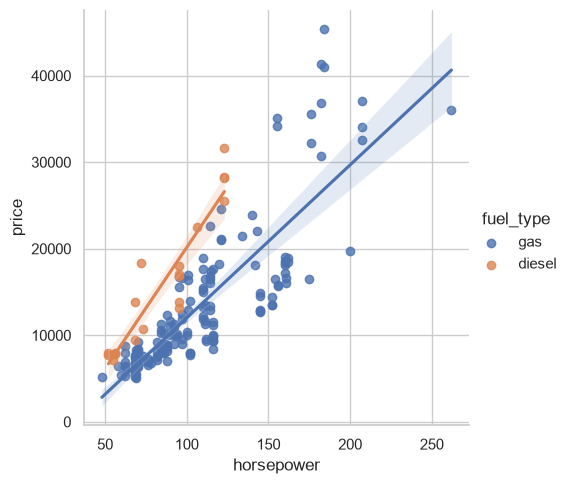

In [22]:
sns.lmplot(x="horsepower", y="price", hue="fuel_type", data=df);